# Movie Rating Prediction — Dataset Audit

**Notebook:** `01_dataset_audit.ipynb`
**Scope:** understand the raw IMDb India movies dataset before any preprocessing or modelling.

This notebook is **read-only with respect to the raw data**: the CSV is loaded into memory and never written back.
Where text columns are parsed into numbers (e.g. `"(2019)"` → `2019`), the parsed values live in a separate
in-memory audit frame and are used for inspection only. No rows are dropped, no values are imputed, no
train/test split is made and no model is trained.

## 1. Project Objective

The CodSoft task is to **build a model that predicts the rating of a movie** from movie-related features such as
genre, director and actors, using **regression** techniques. The goal is to analyse historical movie data and
estimate the rating users or critics give to a film.

Because the task asks us to predict a movie's *rating*, the candidate target is the `Rating` column. Section 10
checks that this column is numeric, bounded and suitable as a regression target.

## 2. Dataset Loading

The file is **not valid UTF-8** (it contains single-byte accented characters such as `0xE9` = `é`), so it is read with
`encoding="latin-1"`. Paths are relative to the project folder, so the notebook runs from either the project root
or the `notebooks/` directory.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns

# Resolve the project root whether the notebook is run from notebooks/ or the project root
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "dataset" / "IMDb Movies India.csv"
FIG_DIR = PROJECT_ROOT / "visualizations"
FIG_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

# Plot styling: one accessible hue for single-series charts, recessive grid and axes
PRIMARY = "#2a78d6"
ACCENT = "#eb6834"
MUTED = "#52514e"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.edgecolor": "#c9c8c2",
    "axes.labelcolor": "#0b0b0b",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "grid.color": "#e6e5e0",
    "xtick.color": MUTED,
    "ytick.color": MUTED,
})

def save_fig(fig, name):
    """Save a figure to the project's visualizations/ folder."""
    fig.savefig(FIG_DIR / name, dpi=120, bbox_inches="tight")

print(f"Dataset path: {DATA_PATH.relative_to(PROJECT_ROOT)}")
print(f"File exists : {DATA_PATH.exists()}")

Dataset path: dataset\IMDb Movies India.csv
File exists : True


In [2]:
# Confirm the encoding choice: the raw bytes are not valid UTF-8
raw_bytes = DATA_PATH.read_bytes()
try:
    raw_bytes.decode("utf-8")
    print("File decodes as UTF-8")
except UnicodeDecodeError as err:
    print(f"Not valid UTF-8: {err}")

high_bytes = sorted({b for b in raw_bytes if b >= 0x80})
print("Non-ASCII byte values present:", [hex(b) for b in high_bytes])
print("Any bytes in 0x80–0x9F (where latin-1 and cp1252 differ):", any(0x80 <= b <= 0x9F for b in high_bytes))

Not valid UTF-8: 'utf-8' codec can't decode byte 0xe1 in position 76763: invalid continuation byte
Non-ASCII byte values present: ['0xdf', '0xe1', '0xe7', '0xe8', '0xe9', '0xeb', '0xec', '0xed', '0xef', '0xf0', '0xf1', '0xf3', '0xf4', '0xf6', '0xfa', '0xfb', '0xfc']
Any bytes in 0x80–0x9F (where latin-1 and cp1252 differ): False


All non-ASCII bytes are in the `0xA0–0xFF` range, where Latin-1 and Windows-1252 agree, so `latin-1` decodes every
character unambiguously.

In [3]:
df = pd.read_csv(DATA_PATH, encoding="latin-1")
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


## 3. Dataset Dimensions

In [4]:
n_rows, n_cols = df.shape
print(f"Rows   : {n_rows:,}")
print(f"Columns: {n_cols}")

Rows   : 15,509
Columns: 10


## 4. Column Overview

The table below combines the pandas data type, non-null count, null count and number of distinct values for each column.

In [5]:
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "null": df.isna().sum(),
    "unique": df.nunique(),
})
overview

,dtype,non_null,null,unique
Name,str,15509,0,13838
Year,str,14981,528,102
Duration,str,7240,8269,182
Genre,str,13632,1877,485
Rating,float64,7919,7590,84
Votes,str,7920,7589,2034
Director,str,14984,525,5938
Actor 1,str,13892,1617,4718
Actor 2,str,13125,2384,4891
Actor 3,str,12365,3144,4820


**Observation:** only `Rating` is loaded as a numeric (`float64`) column. `Year`, `Duration` and `Votes` hold
numeric information but are stored as text (e.g. `"(2019)"`, `"109 min"`, `"25,732"`), so they will need parsing.

## 5. Sample Records

The first rows of the file are sorted alphabetically by `Name`, so titles starting with punctuation appear first.
A random sample (fixed seed for reproducibility) gives a more representative view.

In [6]:
df.sample(10, random_state=42)

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
11115,Puchki Das,NaN,NaN,"Drama, Fantasy, Romance",NaN,NaN,Nikunj Rathod,NaN,NaN,NaN
2921,Chauhar,(2017),123 min,Drama,6.8,15,Raghubeer Singh,Muntazir Ahmad,Richa Dixit,Vivek Jha
3463,Darpan,(1941),NaN,NaN,NaN,NaN,A.H. Essa,NaN,NaN,NaN
2495,Bombay,(1949),NaN,NaN,NaN,NaN,C.R. Bajaj,Bhudo Advani,Choudhry,Uday Kumar
15263,Yeh Laal Rang,(2005),NaN,Thriller,NaN,NaN,NaN,NaN,NaN,NaN
11165,Pyaar Impossible!,(2010),140 min,"Comedy, Romance",4.6,"3,023",Jugal Hansraj,Priyanka Chopra Jonas,Anupam Kher,Uday Chopra
8371,Luck,(2009),141 min,"Action, Adventure, Drama",4.8,"2,513",Soham Shah,Mithun Chakraborty,Sanjay Dutt,Imran Khan
6929,Jwaala Daaku,(1981),NaN,Action,5.3,9,R.P. Swamy,Mahendra Sandhu,Asha Sachdev,Farida Jalal
4246,Duniya Na Mane,(1937),166 min,Drama,6.9,31,Shantaram Rajaram Vankudre,Shanta Apte,Keshavrao Date,Vimala Vasishta
3312,Dada,(1949),NaN,NaN,NaN,NaN,Harish,Shyam,Munawwar Sultana,Sheikh Mukhtar


## 6. Missing Value Analysis

Missing values are counted per column. Nothing is filled or dropped at this stage.

In [7]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
}).sort_values("missing_pct", ascending=False)
missing

,missing_count,missing_pct
Duration,8269,53.32
Rating,7590,48.94
Votes,7589,48.93
Actor 3,3144,20.27
Actor 2,2384,15.37
Genre,1877,12.10
Actor 1,1617,10.43
Year,528,3.40
Director,525,3.39
Name,0,0.00


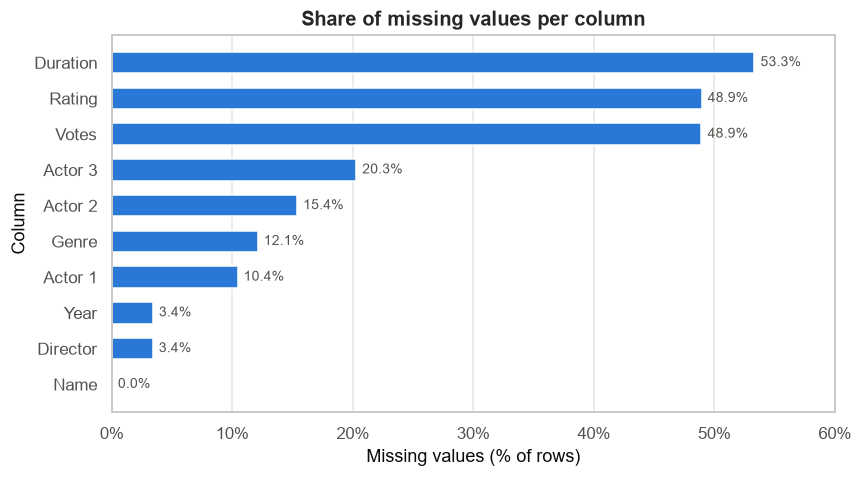

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_data = missing.sort_values("missing_pct")
bars = ax.barh(plot_data.index, plot_data["missing_pct"], color=PRIMARY, height=0.6)
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in plot_data["missing_pct"]], padding=4, color=MUTED, fontsize=9)
ax.set_title("Share of missing values per column")
ax.set_xlabel("Missing values (% of rows)")
ax.set_ylabel("Column")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xlim(0, 60)
ax.grid(axis="y", visible=False)
fig.tight_layout()
save_fig(fig, "01_missing_values.png")
plt.show()

Missing values are not independent across columns. The checks below look at how `Rating` and `Votes` co-occur,
how complete the rows with a rating are, and whether some rows contain nothing except a title.

In [9]:
rating_missing = df["Rating"].isna()
votes_missing = df["Votes"].isna()
print("Rating and Votes co-missingness:")
print(pd.crosstab(rating_missing.rename("Rating missing"), votes_missing.rename("Votes missing")))

only_name = df.drop(columns="Name").isna().all(axis=1)
print(f"\nRows where every column except Name is missing: {only_name.sum()}")

Rating and Votes co-missingness:
Votes missing   False  True 
Rating missing              
False            7919      0
True                1   7589

Rows where every column except Name is missing: 8


In [10]:
rated = df[df["Rating"].notna()]
print(f"Rows with a Rating: {len(rated):,} of {len(df):,} ({len(rated) / len(df):.1%})\n")
pd.DataFrame({
    "missing_in_rated_rows": rated.isna().sum(),
    "missing_pct_in_rated_rows": (rated.isna().mean() * 100).round(2),
})

Rows with a Rating: 7,919 of 15,509 (51.1%)



,missing_in_rated_rows,missing_pct_in_rated_rows
Name,0,0.00
Year,0,0.00
Duration,2068,26.11
Genre,102,1.29
Rating,0,0.00
Votes,0,0.00
Director,5,0.06
Actor 1,125,1.58
Actor 2,200,2.53
Actor 3,292,3.69


**Observations**

- `Rating` is missing for roughly half of the rows, and `Votes` is missing in almost exactly the same rows.
  Rows without a rating cannot be used as supervised training examples.
- Within the rows that *do* have a rating, `Duration` remains the most incomplete feature; `Genre`, `Director` and the
  actor columns have comparatively few gaps.
- A small number of rows contain only a title and no other information.

## 7. Duplicate Analysis

Two kinds of duplication are checked: rows that are identical in every column, and rows that share the same
`Name` and `Year` but differ elsewhere (possible duplicate entries, or genuinely different films with the same title).
Nothing is removed.

In [11]:
exact_dupes = df.duplicated()
print(f"Exact duplicate rows (excluding first occurrence): {exact_dupes.sum()} ({exact_dupes.mean():.2%} of rows)")
print(f"Rows involved in an exact duplicate pair        : {df.duplicated(keep=False).sum()}")
df[df.duplicated(keep=False)].sort_values(["Name", "Year"])

Exact duplicate rows (excluding first occurrence): 6 (0.04% of rows)
Rows involved in an exact duplicate pair        : 12


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1249,Arab Ka Sona - Abu Kaalia,(1979),NaN,Action,NaN,NaN,Master Bhagwan,Meena Rai,Dara Singh,NaN
1250,Arab Ka Sona - Abu Kaalia,(1979),NaN,Action,NaN,NaN,Master Bhagwan,Meena Rai,Dara Singh,NaN
1768,Balidan,(1992),NaN,Drama,NaN,NaN,NaN,NaN,NaN,NaN
1769,Balidan,(1992),NaN,Drama,NaN,NaN,NaN,NaN,NaN,NaN
4722,First Time - Pehli Baar,(2009),NaN,NaN,NaN,NaN,Raja Bundela,Zeenat Aman,Nitin Arora,Raj Babbar
4723,First Time - Pehli Baar,(2009),NaN,NaN,NaN,NaN,Raja Bundela,Zeenat Aman,Nitin Arora,Raj Babbar
9712,Musafir,NaN,NaN,Thriller,NaN,NaN,Shiva Dagar,NaN,NaN,NaN
9713,Musafir,NaN,NaN,Thriller,NaN,NaN,Shiva Dagar,NaN,NaN,NaN
13068,Shivani,(2019),NaN,Crime,NaN,NaN,Ugresh Prasad Ujala,Santosh,NaN,NaN
13069,Shivani,(2019),NaN,Crime,NaN,NaN,Ugresh Prasad Ujala,Santosh,NaN,NaN


In [12]:
name_year_dupes = df.duplicated(subset=["Name", "Year"], keep=False) & ~df.duplicated(keep=False)
print(f"Rows sharing Name + Year with another row but NOT exact duplicates: {name_year_dupes.sum()}")
print(f"Exact duplicates among rows with a Rating: {rated.duplicated().sum()}")
print(f"Name + Year repeats among rows with a Rating: {rated.duplicated(subset=['Name', 'Year']).sum()}")
df[name_year_dupes].sort_values(["Name", "Year"]).head(12)

Rows sharing Name + Year with another row but NOT exact duplicates: 36
Exact duplicates among rows with a Rating: 0
Name + Year repeats among rows with a Rating: 3


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
135,A Ballad of Maladies,(2016),86 min,"Documentary, Music",NaN,NaN,Sarvnik Kaur,Tushar Madhav,NaN,NaN
136,A Ballad of Maladies,(2016),86 min,"Documentary, History, Music",NaN,NaN,Sarvnik Kaur,Tushar Madhav,NaN,NaN
585,Achanak,(1988),NaN,Thriller,NaN,NaN,Rakesh Kashyap,Om Puri,Kunickaa Sadanand,Kanwaljit Singh
586,Achanak,(1988),NaN,Drama,NaN,NaN,Kavi Raz,Alka,Amarjeet Kaur,Kavi Raz
953,Amrit,(1941),153 min,NaN,NaN,NaN,Master Vinayak,Dada Salvi,Baburao Pendharkar,Lalita Pawar
954,Amrit,(1941),162 min,NaN,NaN,NaN,Master Vinayak,Dada Salvi,Baburao Pendharkar,Lalita Pawar
2654,Campus,(2000),NaN,Romance,NaN,NaN,Shefali Shah,Aryan Vaid,Arif Zakaria,NaN
2655,Campus,(2000),NaN,Romance,NaN,NaN,NaN,NaN,NaN,NaN
4133,Dost,(1944),NaN,Drama,6.0,6,Shaukat Hussain Rizvi,Maya Banerjee,Husn Banu,Kanhaiyalal Chaturvedi
4137,Dost,(1944),NaN,Drama,NaN,NaN,Sm Yusuf,NaN,NaN,NaN


**Observations**

- The exact duplicates are few and are all rows **without** a rating, so they do not affect the modelling subset.
- Several `Name` + `Year` pairs appear more than once with different directors, casts or genres. Some look like
  distinct films that share a title (e.g. different directors), others look like partial duplicates of the same film
  (e.g. same director and cast, different duration or genre list). These need a deliberate decision later and should
  not be removed automatically.

## 8. Numerical Column Analysis

As loaded, only `Rating` is numeric. `Year`, `Duration` and `Votes` contain numbers inside formatted text.
To describe them, they are parsed into a **separate audit frame** with `errors="coerce"`: values that do not match
the expected format become `NaN`, and Section 11 examines exactly which values those are.

In [13]:
print("Numeric columns as loaded:", df.select_dtypes(include="number").columns.tolist())
print("Text columns as loaded   :", df.select_dtypes(exclude="number").columns.tolist())

Numeric columns as loaded: ['Rating']
Text columns as loaded   : ['Name', 'Year', 'Duration', 'Genre', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']


In [14]:
# Audit-only parsed copies; the raw frame `df` is left untouched
audit = pd.DataFrame(index=df.index)
audit["Year"] = pd.to_numeric(df["Year"].str.extract(r"^\((\d{4})\)$")[0], errors="coerce")
audit["Duration_min"] = pd.to_numeric(df["Duration"].str.extract(r"^(\d+) min$")[0], errors="coerce")
audit["Votes"] = pd.to_numeric(df["Votes"].str.replace(",", "", regex=False), errors="coerce")
audit["Rating"] = df["Rating"]

audit.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Year,14981.0,1987.01,25.42,1913.0,1968.0,1991.0,2009.0,2022.0
Duration_min,7240.0,128.13,28.91,2.0,110.0,131.0,147.0,321.0
Votes,7919.0,1938.52,11602.42,5.0,16.0,55.0,404.0,591417.0
Rating,7919.0,5.84,1.38,1.1,4.9,6.0,6.8,10.0


**Observations**

- `Year` covers roughly a century of films.
- `Duration_min` has a wide range, including a few very short entries (see Section 11).
- `Votes` is extremely right-skewed: the median is far below the mean and the maximum is several orders of
  magnitude above the median. A log scale is needed to look at it meaningfully.

In [15]:
votes_rated = audit.loc[audit["Rating"].notna(), "Votes"]
print("Votes (rated rows) skewness:", round(votes_rated.skew(), 2))
print("Votes percentiles (rated rows):")
votes_rated.quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.99]).astype(int)

Votes (rated rows) skewness: 25.39
Votes percentiles (rated rows):


0.10        8
0.25       16
0.50       55
0.75      404
0.90     2966
0.99    34265
Name: Votes, dtype: int64

## 9. Categorical / Text Column Analysis

The remaining columns are free-text categorical fields: `Name`, `Genre`, `Director`, `Actor 1`, `Actor 2`, `Actor 3`.

In [16]:
cat_cols = ["Name", "Genre", "Director", "Actor 1", "Actor 2", "Actor 3"]
cat_summary = pd.DataFrame({
    "non_null": df[cat_cols].notna().sum(),
    "unique": df[cat_cols].nunique(),
    "unique_in_rated_rows": rated[cat_cols].nunique(),
    "most_frequent": df[cat_cols].mode().iloc[0],
    "top_count": [df[c].value_counts().iloc[0] for c in cat_cols],
})
cat_summary["unique_ratio"] = (cat_summary["unique"] / cat_summary["non_null"]).round(3)
cat_summary

,non_null,unique,unique_in_rated_rows,most_frequent,top_count,unique_ratio
Name,15509,13838,7372,Anjaam,7,0.892
Genre,13632,485,432,Drama,2780,0.036
Director,14984,5938,3139,Jayant Desai,58,0.396
Actor 1,13892,4718,2551,Ashok Kumar,158,0.340
Actor 2,13125,4891,2873,Rekha,83,0.373
Actor 3,12365,4820,3064,Pran,91,0.390


### 9.1 Genre

`Genre` is a **comma-separated multi-label field** (e.g. `"Drama, Romance"`). Treated as a single string it has
hundreds of distinct combinations, but it is built from a much smaller set of individual genre tokens.

In [17]:
print("Most frequent Genre strings (as stored):")
print(df["Genre"].value_counts().head(10).to_string())

genre_tokens = df["Genre"].dropna().str.split(",").explode().str.strip()
genres_per_movie = df["Genre"].dropna().str.split(",").str.len()
print(f"\nDistinct Genre strings : {df['Genre'].nunique()}")
print(f"Distinct genre tokens  : {genre_tokens.nunique()}")
print("Genres listed per movie:", genres_per_movie.value_counts().sort_index().to_dict())

Most frequent Genre strings (as stored):
Genre
Drama                   2780
Action                  1289
Thriller                 779
Romance                  708
Drama, Romance           524
Comedy                   495
Action, Crime, Drama     455
Drama, Family            418
Horror                   322
Action, Drama            316

Distinct Genre strings : 485
Distinct genre tokens  : 24
Genres listed per movie: {1: 7431, 2: 2961, 3: 3240}


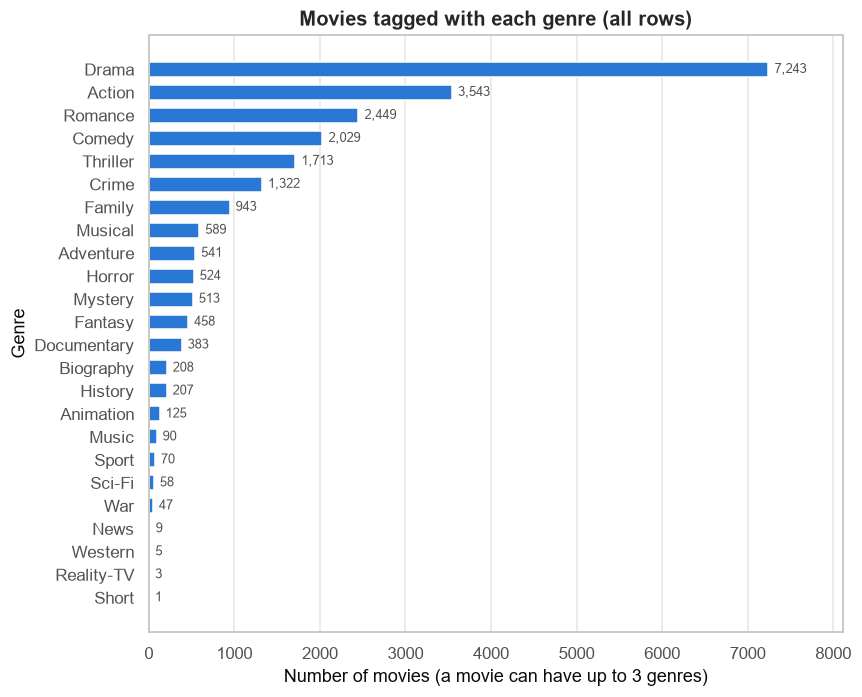

In [18]:
token_counts = genre_tokens.value_counts()

fig, ax = plt.subplots(figsize=(8, 6.5))
plot_data = token_counts.sort_values()
bars = ax.barh(plot_data.index, plot_data.values, color=PRIMARY, height=0.65)
ax.bar_label(bars, labels=[f"{v:,}" for v in plot_data.values], padding=4, color=MUTED, fontsize=8.5)
ax.set_title("Movies tagged with each genre (all rows)")
ax.set_xlabel("Number of movies (a movie can have up to 3 genres)")
ax.set_ylabel("Genre")
ax.set_xlim(0, token_counts.max() * 1.12)
ax.grid(axis="y", visible=False)
fig.tight_layout()
save_fig(fig, "02_genre_frequency.png")
plt.show()

**Observations**

- `Drama` is by far the most common genre token, followed by `Action`, `Romance` and `Comedy`.
- Several tokens are very rare (single-digit counts), which matters for any per-genre encoding.
- Both `Music` and `Musical` exist as separate tokens; whether they should be treated as the same category is a
  decision for preprocessing, not something assumed here.

### 9.2 Director and Actors

These columns contain person names. The key question is how concentrated they are: whether a few names cover
most movies, or whether most names appear only once or twice.

In [19]:
people_cols = ["Director", "Actor 1", "Actor 2", "Actor 3"]
rows = []
for col in people_cols:
    counts = df[col].value_counts()
    rows.append({
        "column": col,
        "unique_names": len(counts),
        "names_appearing_once": int((counts == 1).sum()),
        "pct_names_appearing_once": round((counts == 1).mean() * 100, 1),
        "median_movies_per_name": counts.median(),
        "max_movies_per_name": counts.max(),
    })
pd.DataFrame(rows).set_index("column")

,unique_names,names_appearing_once,pct_names_appearing_once,median_movies_per_name,max_movies_per_name
column,,,,,
Director,5938,3896,65.6,1.0,58
Actor 1,4718,3263,69.2,1.0,158
Actor 2,4891,3283,67.1,1.0,83
Actor 3,4820,3230,67.0,1.0,91


In [20]:
for col in people_cols:
    print(f"Top 10 {col}:")
    print(df[col].value_counts().head(10).to_string(), "\n")

Top 10 Director:
Director
Jayant Desai        58
Kanti Shah          57
Babubhai Mistry     50
Mahesh Bhatt        48
Master Bhagwan      47
Nanabhai Bhatt      46
Dhirubhai Desai     46
David Dhawan        44
Mohammed Hussain    44
B.R. Ishara         44 

Top 10 Actor 1:
Actor 1
Ashok Kumar           158
Dharmendra            140
Jeetendra             140
Mithun Chakraborty    133
Amitabh Bachchan      129
Rajesh Khanna         122
Dev Anand              93
Shashi Kapoor          91
Akshay Kumar           88
Sanjeev Kumar          83 

Top 10 Actor 2:
Actor 2
Rekha                 83
Hema Malini           72
Mithun Chakraborty    63
Dharmendra            61
Mala Sinha            48
Helen                 48
Reena Roy             45
Mumtaz                45
Jaya Prada            44
Shabana Azmi          44 

Top 10 Actor 3:
Actor 3
Pran                  91
Shakti Kapoor         65
Anupam Kher           64
Jeevan                59
Prem Chopra           52
Aruna Irani           47
Shatru

In [21]:
# The same person can appear in any of the three actor slots
all_actors = pd.concat([df["Actor 1"], df["Actor 2"], df["Actor 3"]]).dropna()
actor_counts = all_actors.value_counts()
print(f"Distinct actors across Actor 1–3: {actor_counts.size:,}")
print(f"Actors appearing in exactly one movie slot: {(actor_counts == 1).sum():,} ({(actor_counts == 1).mean():.1%})")

slots_per_actor = pd.concat(
    [pd.Series(df[c].dropna().unique()) for c in ["Actor 1", "Actor 2", "Actor 3"]]
).value_counts()
print(f"Actors who appear in more than one slot position: {(slots_per_actor > 1).sum():,}")
print("\nTop 10 actors across all three slots:")
print(actor_counts.head(10).to_string())

Distinct actors across Actor 1–3: 10,288
Actors appearing in exactly one movie slot: 6,821 (66.3%)
Actors who appear in more than one slot position: 2,841

Top 10 actors across all three slots:
Mithun Chakraborty    241
Dharmendra            231
Ashok Kumar           227
Jeetendra             179
Amitabh Bachchan      178
Rekha                 142
Rajesh Khanna         139
Shashi Kapoor         133
Shatrughan Sinha      131
Shakti Kapoor         131


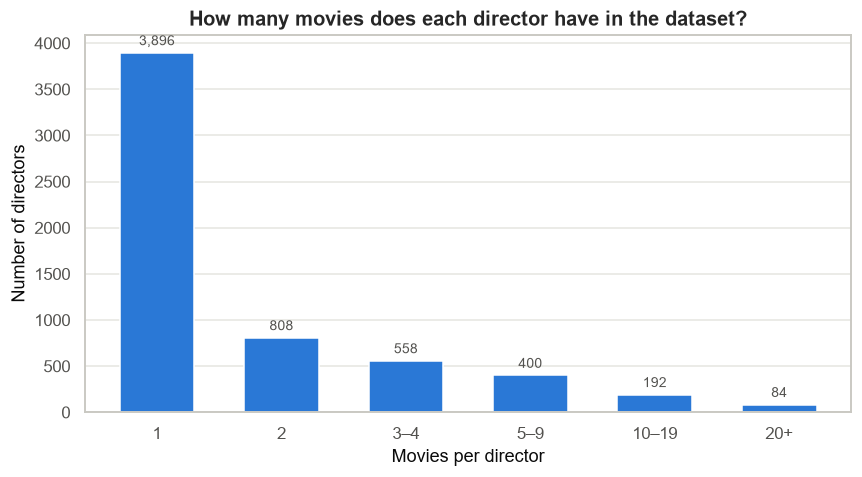

In [22]:
fig, ax = plt.subplots(figsize=(8, 4.5))
director_counts = df["Director"].value_counts()
bins = [1, 2, 3, 5, 10, 20, 60]
labels = ["1", "2", "3–4", "5–9", "10–19", "20+"]
binned = pd.cut(director_counts, bins=bins, right=False, labels=labels).value_counts().reindex(labels)
bars = ax.bar(binned.index.astype(str), binned.values, color=PRIMARY, width=0.6)
ax.bar_label(bars, labels=[f"{v:,}" for v in binned.values], padding=3, color=MUTED, fontsize=9)
ax.set_title("How many movies does each director have in the dataset?")
ax.set_xlabel("Movies per director")
ax.set_ylabel("Number of directors")
ax.grid(axis="x", visible=False)
fig.tight_layout()
save_fig(fig, "03_movies_per_director.png")
plt.show()

**Observations**

- `Director` and each actor column have thousands of distinct names, and a large share of names appear in only one
  movie. These are **high-cardinality, long-tailed** features.
- The same actor can appear in different slots (`Actor 1`, `Actor 2`, `Actor 3`) for different films, so the slot
  position is not a stable identity for an actor.
- `Name` (the movie title) is close to unique per row and identifies a film rather than describing it.

## 10. Target Variable Analysis — `Rating`

`Rating` is the only column that directly measures how a film was received, and it matches the task
("predict the rating of a movie"). The checks below confirm it is numeric, bounded, and describe its distribution.

In [23]:
rating = df["Rating"]
print(f"Missing ratings : {rating.isna().sum():,} ({rating.isna().mean():.2%})")
print(f"Available       : {rating.notna().sum():,}")
print(f"Min / Max       : {rating.min()} / {rating.max()}")
print(f"Mean            : {rating.mean():.3f}")
print(f"Median          : {rating.median():.3f}")
print(f"Std deviation   : {rating.std():.3f}")
print(f"Skewness        : {rating.skew():.3f}")
print(f"Distinct values : {rating.nunique()}")
print(f"All values have at most 1 decimal place: {bool((rating.dropna().round(1) == rating.dropna()).all())}")
rating.describe().to_frame().T.round(3)

Missing ratings : 7,590 (48.94%)
Available       : 7,919
Min / Max       : 1.1 / 10.0
Mean            : 5.842
Median          : 6.000
Std deviation   : 1.382
Skewness        : -0.346
Distinct values : 84
All values have at most 1 decimal place: True


,count,mean,std,min,25%,50%,75%,max
Rating,7919.0,5.842,1.382,1.1,4.9,6.0,6.8,10.0


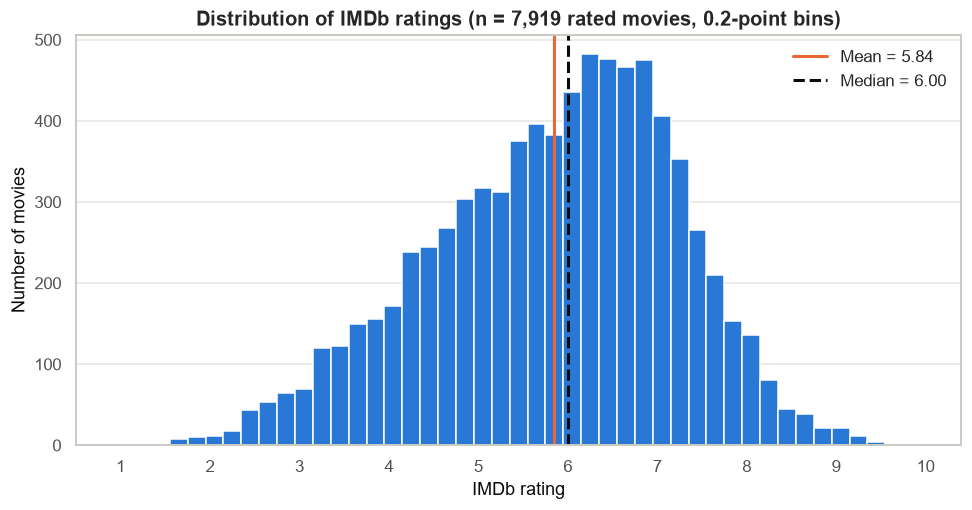

In [24]:
fig, ax = plt.subplots(figsize=(9, 4.8))
r = rating.dropna()
ax.hist(r, bins=np.arange(0.95, 10.15, 0.2), color=PRIMARY, edgecolor="white", linewidth=1)
ax.axvline(r.mean(), color=ACCENT, linewidth=2, label=f"Mean = {r.mean():.2f}")
ax.axvline(r.median(), color="#0b0b0b", linewidth=2, linestyle="--", label=f"Median = {r.median():.2f}")
ax.set_title(f"Distribution of IMDb ratings (n = {len(r):,} rated movies, 0.2-point bins)")
ax.set_xlabel("IMDb rating")
ax.set_ylabel("Number of movies")
ax.set_xticks(range(1, 11))
ax.legend(frameon=False)
ax.grid(axis="x", visible=False)
fig.tight_layout()
save_fig(fig, "04_rating_distribution.png")
plt.show()

**Observations**

- `Rating` is continuous-valued (one decimal place) on the IMDb 1–10 scale, so **regression** is appropriate.
- The distribution is unimodal with a longer left tail (negative skew): the mean is slightly below the median.
- Extreme ratings near 1 or 10 are rare, so errors on those films may be large.
- Only about half of the rows have a rating; the other half cannot be used as labelled training data.

## 11. Data Quality Investigation

Each numeric-in-meaning column is checked against its expected format. Values that do not match are listed rather
than silently coerced.

### 11.1 `Year`

In [25]:
year_str = df["Year"].dropna()
year_ok = year_str.str.fullmatch(r"\(\d{4}\)")
print(f"Non-null Year values: {len(year_str):,}")
print(f"Matching '(YYYY)'   : {year_ok.sum():,}")
print(f"Not matching        : {(~year_ok).sum():,}")
print(f"Parsed range        : {int(audit['Year'].min())}–{int(audit['Year'].max())}")
print(f"Rated movies range  : {int(audit.loc[rating.notna(), 'Year'].min())}–{int(audit.loc[rating.notna(), 'Year'].max())}")
print("\nMost recent years (movie counts; ratings available):")
recent = audit[audit["Year"] >= 2019].groupby("Year").agg(movies=("Rating", "size"), rated=("Rating", "count"))
recent.astype(int)

Non-null Year values: 14,981
Matching '(YYYY)'   : 14,981
Not matching        : 0
Parsed range        : 1913–2022
Rated movies range  : 1917–2021

Most recent years (movie counts; ratings available):


,movies,rated
Year,,
2019.0,410,249
2020.0,320,167
2021.0,392,78
2022.0,38,0


**Observation:** every non-null `Year` follows the `(YYYY)` format; the problem is only the parentheses (text type)
and 528 missing values. Recent years have a much lower share of rated movies, which is consistent with releases that
had not accumulated ratings when the data was collected (an interpretation, not verified from the data).

### 11.2 `Duration`

In [26]:
dur_str = df["Duration"].dropna()
dur_ok = dur_str.str.fullmatch(r"\d+ min")
print(f"Non-null Duration values: {len(dur_str):,}")
print(f"Matching '<N> min'      : {dur_ok.sum():,}")
print(f"Not matching            : {(~dur_ok).sum():,}")
print("\nShortest durations:")
short = audit["Duration_min"] < 45
display(df.loc[short, ["Name", "Year", "Duration", "Genre", "Rating"]])
print("Longest durations:")
display(df.loc[audit["Duration_min"].nlargest(5).index, ["Name", "Year", "Duration", "Genre", "Rating"]])

Non-null Duration values: 7,240
Matching '<N> min'      : 7,240
Not matching            : 0

Shortest durations:


,Name,Year,Duration,Genre,Rating
7646,Khota Ishq?: What is the sex of love?,(2015),2 min,"Documentary, Short",NaN
10974,Pratibimbo,(2020),21 min,"Crime, Drama, Mystery",7.8
11716,Ramyug,NaN,37 min,"Action, Drama, Fantasy",NaN


Longest durations:


,Name,Year,Duration,Genre,Rating
4902,Gangs of Wasseypur,(2012),321 min,"Action, Comedy, Crime",8.2
1345,Athidhi,(2007),300 min,Action,5.6
13750,Tamas,(1988),298 min,Drama,NaN
11827,Reason,(2018),261 min,Documentary,9.1
8251,LOC: Kargil,(2003),255 min,"Drama, History, War",5.2


**Observation:** the format is consistent (`"<N> min"`), but more than half of all values are missing, and a few
entries are far shorter than a feature film (e.g. a 2-minute entry tagged `Short`). Whether these belong in a
feature-film rating model is a preprocessing decision.

### 11.3 `Votes`

In [27]:
votes_str = df["Votes"].dropna()
votes_ok = votes_str.str.fullmatch(r"\d{1,3}(,\d{3})*")
print(f"Non-null Votes values           : {len(votes_str):,}")
print(f"Matching digits with thousands ',': {votes_ok.sum():,}")
print(f"Values containing ','           : {votes_str.str.contains(',').sum():,}")
print(f"Not matching                    : {(~votes_ok).sum():,}")
df.loc[votes_str[~votes_ok].index]

Non-null Votes values           : 7,920
Matching digits with thousands ',': 7,919
Values containing ','           : 1,371
Not matching                    : 1


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
9500,Moonlight: Unfortunately a Love Story,(2006),NaN,Comedy,NaN,$5.16M,Raman Bharadwaj,Kim Sharma,Shekhar Suman,Perizaad Zorabian


**Observations**

- `Votes` uses a thousands separator (`"25,732"`), so a plain numeric cast fails; the comma must be removed.
- One row contains `"$5.16M"` in `Votes`. This looks like a monetary value placed in the wrong column. It is also the
  single row that has `Votes` but no `Rating`. It is not a valid vote count.

### 11.4 `Rating`

In [28]:
print(f"Ratings outside [1, 10]: {((rating < 1) | (rating > 10)).sum()}")
print(f"Rows with Rating but no Votes: {(rating.notna() & df['Votes'].isna()).sum()}")
print(f"Rows with Votes but no Rating: {(rating.isna() & df['Votes'].notna()).sum()}")
print("\nRated movies with the fewest votes:")
audit.loc[rating.notna(), "Votes"].value_counts().sort_index().head(8)

Ratings outside [1, 10]: 0
Rows with Rating but no Votes: 0
Rows with Votes but no Rating: 1

Rated movies with the fewest votes:


Votes
5.0     164
6.0     213
7.0     224
8.0     227
9.0     221
10.0    175
11.0    157
12.0    136
Name: count, dtype: int64

**Observation:** all ratings lie in the valid IMDb range with one decimal place. Many ratings are based on very few
votes (the minimum is 5), so some ratings are likely noisy. This is a property of the target, not a formatting error.

### 11.5 Text fields: titles and encoding

In [29]:
name = df["Name"]
print(f"Blank / whitespace-only titles        : {name.str.strip().eq('').sum()}")
print(f"Titles with leading/trailing spaces   : {(name != name.str.strip()).sum()}")
print(f"Titles starting with '#'              : {name.str.startswith('#').sum()}")
non_ascii = df[cat_cols].apply(lambda s: s.dropna().str.contains(r"[^\x00-\x7f]").sum())
print("\nValues containing non-ASCII (accented) characters per column:")
print(non_ascii.to_string())
print("\nExamples:", df.loc[name.str.contains(r"[^\x00-\x7f]"), "Name"].tolist())
print("\nRow with a blank title:")
df[name.str.strip().eq("")]

Blank / whitespace-only titles        : 1
Titles with leading/trailing spaces   : 1
Titles starting with '#'              : 3

Values containing non-ASCII (accented) characters per column:
Name         3
Genre        0
Director    19
Actor 1      8
Actor 2      2
Actor 3      8

Examples: ['Haré Rama Haré Krishna', 'Kabhi Ajnabi Thé', 'Vaña Vaasiyon']

Row with a blank title:


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia


**Observations**

- One row has a blank title (`" "`) but otherwise contains genre and cast information, and no rating.
- Accented characters decode correctly with Latin-1 (e.g. `Haré Rama Haré Krishna`). If the same person is spelled
  with and without accents elsewhere, the names would count as different categories; this has not been checked.

## 12. Initial Relationships with `Rating`

This section uses only the rows with a rating. It is **exploratory**: correlations and group summaries describe
associations in this dataset and do not establish causes. Nothing computed here is used to build features.

In [30]:
rated_audit = audit[audit["Rating"].notna()].copy()
rated_audit["log10_Votes"] = np.log10(rated_audit["Votes"])

rows = []
for col in ["Year", "Duration_min", "log10_Votes"]:
    pair = rated_audit[[col, "Rating"]].dropna()
    rows.append({
        "feature": col,
        "n_pairs": len(pair),
        "pearson_r": round(pair[col].corr(pair["Rating"], method="pearson"), 3),
        "spearman_rho": round(pair[col].corr(pair["Rating"], method="spearman"), 3),
    })
pd.DataFrame(rows).set_index("feature")

,n_pairs,pearson_r,spearman_rho
feature,,,
Year,7919,-0.167,-0.128
Duration_min,5851,-0.031,-0.024
log10_Votes,7919,0.140,0.137


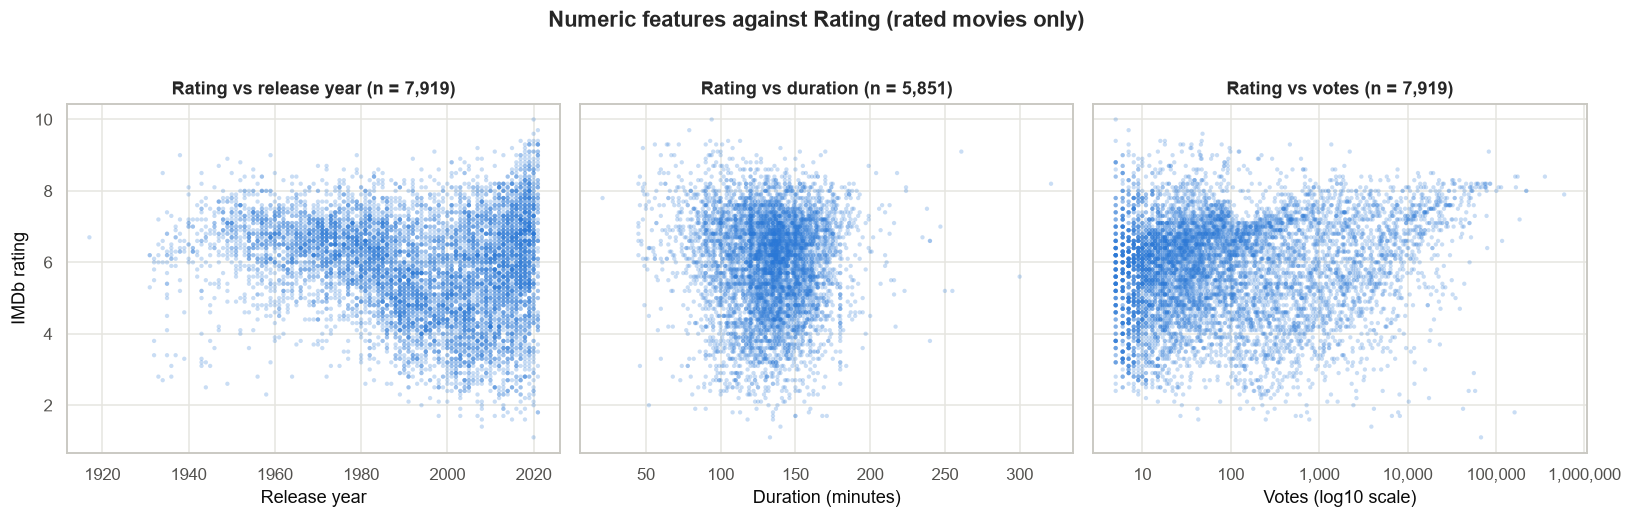

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
panels = [
    ("Year", "Release year"),
    ("Duration_min", "Duration (minutes)"),
    ("log10_Votes", "Votes (log10 scale)"),
]
for ax, (col, label) in zip(axes, panels):
    pair = rated_audit[[col, "Rating"]].dropna()
    ax.scatter(pair[col], pair["Rating"], s=8, alpha=0.25, color=PRIMARY, edgecolors="none")
    ax.set_title(f"Rating vs {label.split(' (')[0].lower()} (n = {len(pair):,})", fontsize=12)
    ax.set_xlabel(label)
axes[0].set_ylabel("IMDb rating")
axes[2].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{10 ** x:,.0f}"))
fig.suptitle("Numeric features against Rating (rated movies only)", fontweight="bold", y=1.02)
fig.tight_layout()
save_fig(fig, "05_numeric_vs_rating.png")
plt.show()

Rating by release decade (rated movies):


Decade,1910,1930,1940,1950,1960,1970,1980,1990,2000,2010,2020
movies,1.0,66.00,151.00,385.00,551.00,826.00,1134.00,1132.00,1448.00,1980.00,245.00
median,6.7,6.20,6.80,6.70,6.50,6.50,6.00,5.20,5.30,6.00,6.70
std,NaN,1.31,1.21,0.94,0.86,0.91,1.12,1.28,1.47,1.52,1.81


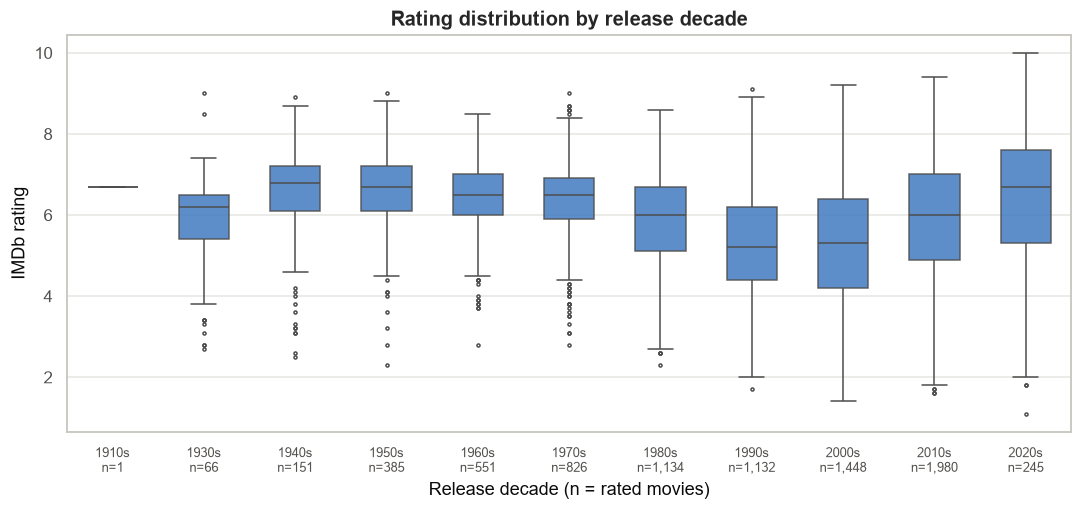

In [32]:
rated_audit["Decade"] = (rated_audit["Year"] // 10 * 10).astype(int)
decade_counts = rated_audit["Decade"].value_counts().sort_index()
print("Rating by release decade (rated movies):")
display(rated_audit.groupby("Decade")["Rating"].agg(movies="size", median="median", std="std").round(2).T)

fig, ax = plt.subplots(figsize=(10, 4.8))
order = sorted(rated_audit["Decade"].unique())
sns.boxplot(data=rated_audit, x="Decade", y="Rating", order=order, color=PRIMARY,
            width=0.55, fliersize=2, linewidth=1, boxprops={"alpha": 0.85}, ax=ax)
ax.set_xticks(range(len(order)))
ax.set_xticklabels([f"{d}s\nn={decade_counts[d]:,}" for d in order], fontsize=8.5)
ax.set_title("Rating distribution by release decade")
ax.set_xlabel("Release decade (n = rated movies)")
ax.set_ylabel("IMDb rating")
ax.grid(axis="x", visible=False)
fig.tight_layout()
save_fig(fig, "06_rating_by_decade.png")
plt.show()

In [33]:
# Rating spread by vote-count band (bands chosen on round numbers, not tuned)
vote_bands = pd.cut(rated_audit["Votes"], bins=[0, 10, 100, 1_000, 10_000, np.inf],
                    labels=["5–10", "11–100", "101–1,000", "1,001–10,000", "> 10,000"])
rated_audit.groupby(vote_bands, observed=True)["Rating"].agg(
    movies="size", median="median", std="std", min="min", max="max").round(2)

,movies,median,std,min,max
Votes,,,,,
5–10,1224,5.7,1.40,2.3,10.0
11–100,3475,6.0,1.28,1.6,9.6
"101–1,000",1849,5.8,1.44,1.6,9.3
"1,001–10,000",1028,6.1,1.37,1.4,9.3
"> 10,000",343,7.3,1.28,1.1,9.1


The next view summarises rating per **genre token**. A movie tagged `"Drama, Romance"` contributes to both genres, so
groups overlap. Only genres with at least 50 rated movies are shown, because averages over a handful of films are unstable.

In [34]:
MIN_MOVIES = 50
genre_long = (
    df.loc[rating.notna(), ["Genre", "Rating"]]
    .dropna(subset=["Genre"])
    .assign(Genre=lambda d: d["Genre"].str.split(","))
    .explode("Genre")
    .assign(Genre=lambda d: d["Genre"].str.strip())
)
genre_stats = (
    genre_long.groupby("Genre")["Rating"]
    .agg(movies="size", mean="mean", median="median", std="std")
    .round(2)
    .sort_values("median", ascending=False)
)
print(f"Genres with fewer than {MIN_MOVIES} rated movies (excluded from the chart):")
print(genre_stats[genre_stats["movies"] < MIN_MOVIES]["movies"].to_dict())
genre_stats[genre_stats["movies"] >= MIN_MOVIES]

Genres with fewer than 50 rated movies (excluded from the chart):
{'News': 2, 'War': 34, 'Western': 3, 'Sci-Fi': 37}


,movies,mean,median,std
Genre,,,,
Documentary,143,7.61,7.70,0.99
Biography,142,6.82,7.00,1.23
History,128,6.80,6.95,1.19
Music,61,6.14,6.60,1.60
Sport,51,6.49,6.60,1.45
Musical,498,6.16,6.50,1.36
Family,663,6.20,6.30,1.11
Drama,4924,6.00,6.20,1.32
Fantasy,205,5.82,6.20,1.39


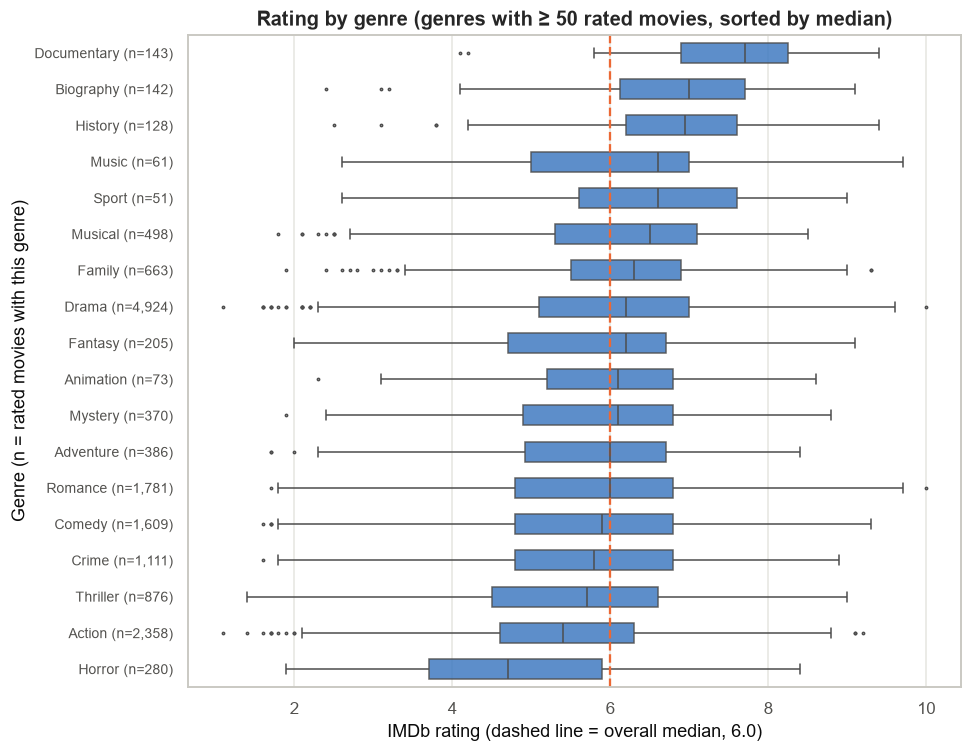

In [35]:
shown = genre_stats[genre_stats["movies"] >= MIN_MOVIES].index.tolist()
fig, ax = plt.subplots(figsize=(9, 7))
sns.boxplot(data=genre_long[genre_long["Genre"].isin(shown)], y="Genre", x="Rating", order=shown,
            color=PRIMARY, width=0.55, fliersize=1.5, linewidth=1, boxprops={"alpha": 0.85}, ax=ax)
ax.set_yticks(range(len(shown)))
ax.set_yticklabels([f"{g} (n={genre_stats.loc[g, 'movies']:,})" for g in shown], fontsize=9)
ax.axvline(rating.median(), color=ACCENT, linewidth=1.5, linestyle="--")
ax.set_title(f"Rating by genre (genres with ≥ {MIN_MOVIES} rated movies, sorted by median)")
ax.set_xlabel(f"IMDb rating (dashed line = overall median, {rating.median():.1f})")
ax.set_ylabel("Genre (n = rated movies with this genre)")
ax.grid(axis="y", visible=False)
fig.tight_layout()
save_fig(fig, "07_rating_by_genre.png")
plt.show()

For directors and actors, per-name average ratings are **not** plotted: most names have only one or two rated films,
so their averages would mostly reflect single movies. The table below shows how much rating history each name has.

In [36]:
rows = []
for col in people_cols:
    counts = rated[col].value_counts()
    rows.append({
        "column": col,
        "names_in_rated_rows": len(counts),
        "with_1_rated_movie": int((counts == 1).sum()),
        "with_5plus_rated_movies": int((counts >= 5).sum()),
        "rated_rows_covered_by_5plus_names": int(rated[col].isin(counts[counts >= 5].index).sum()),
    })
pd.DataFrame(rows).set_index("column")

,names_in_rated_rows,with_1_rated_movie,with_5plus_rated_movies,rated_rows_covered_by_5plus_names
column,,,,
Director,3139,2021,375,3974
Actor 1,2551,1802,277,4810
Actor 2,2873,1942,336,4273
Actor 3,3064,2067,348,3869


**Observations** (associations only, not causes)

- **Year:** the linear correlation is weak (Pearson r ≈ −0.17), but the pattern by decade is not linear. Median
  ratings are highest for the 1940s–1970s, lowest for the 1990s–2000s, and rise again for the 2010s–2020s. The spread
  of ratings is also wider from the 1980s onward. The 1910s group contains a single film.
- **Duration:** almost no linear association with `Rating` (r ≈ −0.03) among the rows where it is available.
- **Votes:** weak overall correlation (r ≈ 0.14 on the log scale). Films with few votes span nearly the whole rating
  range. The band with more than 10,000 votes has a clearly higher median (7.3, versus 5.7–6.1 for the lower
  bands), although its spread is similar. That band contains only 343 films.
- **Genre:** Documentary, Biography and History have the highest median ratings; Horror and Action the lowest.
  The spread within every genre is wide (standard deviation roughly 1–1.6 points), so genre alone separates ratings
  only partially.
- **Director / actors:** most names have only one rated film, so per-name rating summaries would be unreliable.
- `Votes` is only available where `Rating` is available and is itself a product of audience response, so it needs
  careful consideration before being used as a predictor (see Section 13).

## 13. Initial Feature Assessment

This assessment uses only what the dataset shows. The final encoding strategy is **not** chosen here.

In [37]:
assessment = pd.DataFrame({
    "stored_as": df.dtypes.astype(str),
    "meaning": ["title", "numeric (year)", "numeric (minutes)", "multi-label categorical", "numeric target",
                "numeric (count)", "categorical (person)", "categorical (person)", "categorical (person)",
                "categorical (person)"],
    "missing_pct_all": (df.isna().mean() * 100).round(1),
    "missing_pct_rated": (rated.isna().mean() * 100).round(1),
    "unique_in_rated": rated.nunique(),
})
assessment

,stored_as,meaning,missing_pct_all,missing_pct_rated,unique_in_rated
Name,str,title,0.0,0.0,7372
Year,str,numeric (year),3.4,0.0,92
Duration,str,numeric (minutes),53.3,26.1,178
Genre,str,multi-label categorical,12.1,1.3,432
Rating,float64,numeric target,48.9,0.0,84
Votes,str,numeric (count),48.9,0.0,2033
Director,str,categorical (person),3.4,0.1,3139
Actor 1,str,categorical (person),10.4,1.6,2551
Actor 2,str,categorical (person),15.4,2.5,2873
Actor 3,str,categorical (person),20.3,3.7,3064


| Category | Columns | Evidence from this audit |
|---|---|---|
| **Target** | `Rating` | Numeric, 1–10, one decimal; task asks to predict rating |
| **Candidate numerical features** | `Year`, `Duration`, `Votes` | Numeric meaning, stored as text |
| **Candidate categorical features** | `Genre`, `Director`, `Actor 1`, `Actor 2`, `Actor 3` | Named in the task as rating drivers |
| **High-cardinality features** | `Director`, `Actor 1`, `Actor 2`, `Actor 3`, `Genre` (as a raw string) | Thousands of names (hundreds of genre combinations); many names appear once |
| **Potentially problematic** | `Votes` | Only present when `Rating` is present; reflects audience response, so it may not be known for a new film (**assumption** to confirm against the intended use) |
| | `Name` | Near-unique identifier; not a descriptive feature as-is |
| | `Duration` | ~26% missing even among rated rows |
| **Requires preprocessing** | `Year` | Strip parentheses → integer |
| | `Duration` | Strip `" min"` → integer; review very short entries |
| | `Votes` | Remove thousands separator; handle the `"$5.16M"` value |
| | `Genre` | Split comma-separated list into individual genre tokens |
| | all | Decide how to handle missing values and partial duplicates |
| **Possible feature engineering** | `Genre` | Multi-hot genre indicators; number of genres |
| | `Director`, actors | Frequency / experience-style features (number of films per person); grouping rare names; actor slot-independent treatment |
| | `Year` | Decade or film age |
| | `Votes` | Log transform (heavy right skew), if retained |

**Leakage note:** any feature derived from `Rating` (e.g. a director's average rating) must be computed only on the
training split during modelling, never on the full dataset. No such feature is created in this notebook.

## 14. Initial Findings

The figures in this section are computed directly from the CSV.

In [38]:
summary = {
    "Total rows": f"{len(df):,}",
    "Columns": n_cols,
    "Rows with Rating (usable labelled rows)": f"{len(rated):,} ({len(rated) / len(df):.1%})",
    "Rows without Rating": f"{rating.isna().sum():,} ({rating.isna().mean():.1%})",
    "Exact duplicate rows": f"{df.duplicated().sum()} (none among rated rows: {rated.duplicated().sum() == 0})",
    "Name+Year repeats among rated rows": rated.duplicated(subset=["Name", "Year"]).sum(),
    "Rating range / mean / median / std": f"{rating.min()}–{rating.max()} / {rating.mean():.2f} / {rating.median():.2f} / {rating.std():.2f}",
    "Most-missing feature (all rows)": f"Duration ({df['Duration'].isna().mean():.1%})",
    "Duration missing among rated rows": f"{rated['Duration'].isna().mean():.1%}",
    "Distinct genre tokens / genre strings": f"{genre_tokens.nunique()} / {df['Genre'].nunique()}",
    "Distinct directors (all / rated)": f"{df['Director'].nunique():,} / {rated['Director'].nunique():,}",
    "Distinct actors across 3 slots": f"{actor_counts.size:,}",
    "Malformed Votes values": ", ".join(votes_str[~votes_ok].tolist()),
    "Title-only rows": int(only_name.sum()),
}
pd.Series(summary, name="value").to_frame()

,value
Total rows,"15,509"
Columns,10
Rows with Rating (usable labelled rows),"7,919 (51.1%)"
Rows without Rating,"7,590 (48.9%)"
Exact duplicate rows,6 (none among rated rows: True)
Name+Year repeats among rated rows,3
Rating range / mean / median / std,1.1–10.0 / 5.84 / 6.00 / 1.38
Most-missing feature (all rows),Duration (53.3%)
Duration missing among rated rows,26.1%
Distinct genre tokens / genre strings,24 / 485


### DATASET AUDIT SUMMARY

**Dataset size**
- 15,509 rows × 10 columns, loaded with `encoding="latin-1"` (the file is not valid UTF-8).

**Target variable**
- `Rating`: numeric IMDb rating on a 1–10 scale with one decimal place, which fits a regression task.
- 7,919 rows (51.1%) have a rating. Mean 5.84, median 6.0, standard deviation 1.38. The distribution is
  unimodal with a longer left tail.

**Missing values**
- `Rating` (48.9%) and `Votes` (48.9%) are missing in almost exactly the same rows.
- `Duration` is the most incomplete feature: 53.3% missing overall and about 26% missing among rated rows.
- `Actor 3` 20.3%, `Actor 2` 15.4%, `Genre` 12.1%, `Actor 1` 10.4%, `Year` 3.4%, `Director` 3.4% missing (all rows).
- 8 rows contain only a title.

**Duplicates**
- 6 exact duplicate rows (0.04%). None of them has a rating.
- Several `Name` + `Year` pairs repeat with different details. Some are distinct films that share a title, some look
  like partial duplicates. 3 such repeats are among rated rows. Needs a manual decision.

**Data-quality issues**
- `Year` is stored as `"(YYYY)"` text. The format is consistent.
- `Duration` is stored as `"<N> min"` text. It includes very short entries (2, 21 and 37 minutes).
- `Votes` is stored as text with thousands separators. One value is `"$5.16M"`, which is not a vote count.
- One row has a blank (whitespace-only) title.
- Many ratings are based on very few votes (minimum 5), so the target is likely noisy for obscure films.
- Genre tokens include both `Music` and `Musical`.

**Numerical features (after parsing):** `Year`, `Duration`, `Votes`.

**Categorical features:** `Genre` (multi-label, 24 tokens), `Director`, `Actor 1`, `Actor 2`, `Actor 3`.
`Name` is an identifier.

**High-cardinality columns:** `Director` (5,938 names), `Actor 1` / `Actor 2` / `Actor 3` (about 4,700–4,900 each),
`Genre` as a raw string (485 combinations), `Name`.

**Major preprocessing considerations**
1. Restrict supervised modelling to rows with a `Rating`.
2. Parse `Year`, `Duration` and `Votes` to numbers, and handle the malformed `Votes` value.
3. Choose a missing-value strategy, especially for `Duration`.
4. Split `Genre` into individual tokens (multi-label encoding).
5. Encode high-cardinality person columns in a way that handles rare and unseen names. Any rating-based encoding
   must be fit on training data only to avoid leakage.
6. Decide whether `Votes` is a legitimate input for the intended prediction scenario.
7. Review partial duplicates and very short durations before modelling.

*No rows were removed, no values were imputed, the raw CSV was not modified, and no model was trained.*